In [1]:
import matplotlib.pyplot as plt
import cv2 as cv
from lcLevy.Image import Img
from skimage.measure import ransac, LineModelND
import numpy as np

patch_size = 50
overlap = 25
# Interpolation range, not international police
interpol_range = 5

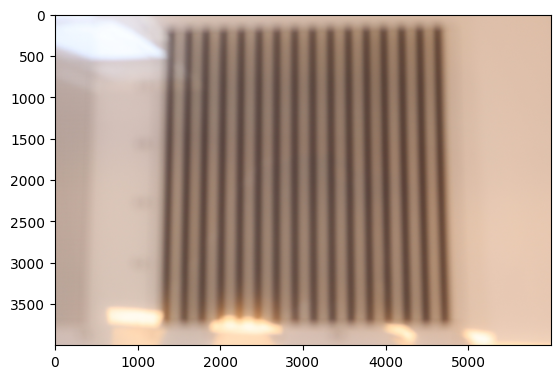

In [2]:
# Traverse over the pixels in the image in chunks
# Analyzing them two at a time just for the sake of this, but I think there
# are probably better solutions we can come up with eventually
# Especially with the need for interpolation

# Maybe make an array as like a map of what all the values are comparing the A_hat between all lateral patches
# Then somehow mesh this, if it's working decently

def reset_img():
    image = cv.imread("EOS_R100_JPG/jpg0006.jpg")
    image = image[:,:,::-1]


# Reading in the image
image = cv.imread("EOS_R100_JPG/jpg0006.jpg")
image = image[:,:,::-1]
# image = image[1500:2000,2000:2500]
# image = image[3000:,:]
# print(len(image))
# print(image[5999, 0])
plt.imshow(image)

In [3]:
# Helper Functions

def lobf(pixels):
    pixels = pixels.reshape(patch_size**2, 3)
    # I'm guessing that the total range is 0-255, but don't really have proof of that
    fit, inliers= ransac(pixels, LineModelND, 200, 2, max_trials = 1000) 
    return (fit, inliers)

def polyfit(pixels):
    pixels = pixels.reshape(patch_size**2, 3)
    polyfit_x, unc_x = np.polyfit(pixels[:][:,2], pixels[:][:,0], 1, cov = True)
    polyfit_y, unc_y = np.polyfit(pixels[:][:,2], pixels[:][:,1], 1, cov = True)
    unc = unc_x[0][0] + unc_y[0][0]
    return[polyfit_x, polyfit_y, unc]


def normalize(vec):
    l = np.sqrt(vec[0]**2 + vec[1]**2+vec[2]**2)
    return [vec[0]/l, vec[1]/l, vec[2]/l]

def airlight_direction(lobf_one, lobf_two):
    # z1 = [50]
    # z2 = [100]
    z1 = 50
    z2 = 100

    # points on plane 1
    # pt1 = [lobf_one.predict_x(z1)[0], lobf_one.predict_y(z1)[0], z1[0]]
    # pt2 = [lobf_one.predict_x(z2)[0], lobf_one.predict_y(z2)[0], z2[0]]
    pt1 = [z1*lobf_one[0][0] + lobf_one[0][1], z1*lobf_one[1][0] + lobf_one[1][1], z1]
    pt2 = [z2*lobf_one[0][0] + lobf_one[0][1], z2*lobf_one[1][0] + lobf_one[1][1], z1]
    norm_one = np.cross(pt1, pt2)
    # points on plane 2
    pt3 = [z1*lobf_two[0][0] + lobf_two[0][1], z1*lobf_two[1][0] + lobf_two[1][1], z2]
    pt4 = [z2*lobf_two[0][0] + lobf_two[0][1], z2*lobf_two[1][0] + lobf_two[1][1], z2]
    # pt3 = [lobf_two.predict_x(z1)[0], lobf_two.predict_y(z1)[0], z1[0]]
    # pt4 = [lobf_two.predict_x(z2)[0], lobf_two.predict_y(z2)[0], z2[0]]
    norm_two = np.cross(pt3, pt4)

    # This assumes, as I believe we can in this problem that the planes intersect at the origin
    intersect = np.cross(norm_one, norm_two)
    return normalize(intersect)

def dist_from_origin(lobf, z):
    return np.sqrt((z*lobf[0][0] + lobf[0][1])**2 + (z*lobf[1][0] + lobf[1][1])**2 + z**2)
    # return np.sqrt(lobf.predict_x([z])**2 + lobf.predict_y([z])**2 + z**2)
    
   
  

def airlight_mag(lobf, A_dir):
    test_zs = range(-100,100,10)
    s = -255
    def avg_dist(s):
        xs = np.mean([np.abs((lobf[0][0]*z + lobf[0][1]) - s*A_dir[0]) for z in test_zs])
        ys = np.mean([np.abs((lobf[1][0]*z + lobf[1][1]) - s*A_dir[1]) for z in test_zs])
        zs = np.mean([np.abs(z - s*A_dir[2]) for z in test_zs])
        return (xs+ys+zs)/3
        
    curr_dist = avg_dist(s)
    new_dist = avg_dist(s+1)
    while new_dist<curr_dist:
        s+=3
        curr_dist = new_dist
        new_dist = avg_dist(s)

    return s

def apply_shift(patch, dir, mag):
    # print(dir)
    # print(dir[0])
    red_frac = (-1)* dir[0]**2  if dir[0]<0 else dir[0]**2
    green_frac = dir[1]**2 *(-1) if dir[1]<0 else dir[1]**2
    blue_frac = dir[2]**2 * (-1) if dir[2]<0 else dir[2]**2

    patch = patch.copy()

    for i in range(len(patch)):
        for j in range(len(patch[0])):
            patch[i][j][0]-= red_frac*mag
            patch[i][j][1]-= green_frac*mag
            patch[i][j][2] -= blue_frac*mag

    return patch

def get_brightness(pixel):
    return (int(pixel[0]) + int(pixel[1]) + int(pixel[2]))/3

def avg_brightness(patch):
    patch = patch.reshape(patch_size**2, 3)
    patch = [get_brightness(pix) for pix in patch]
    return sum(patch) / len(patch)

# False if there isn't enough pixel variation
def highly_variable(patch):
    patch = patch.reshape(patch_size**2, 3)
    patch = [get_brightness(pix) for pix in patch]
    # Reasonable threshold seems like 35-40??
    return np.max(patch)-np.min(patch)>20

# False if the pixel is too white (too close to airlight color already)
def too_white(patch):
    patch = patch.reshape(patch_size**2, 3)
    size = len(patch)
    thresh = 135
    return np.max([np.abs(int(pix[0])-int(pix[1])) for pix in patch]) <thresh and np.max([np.abs(int(pix[0])-int(pix[2])) for pix in patch]) <thresh and avg_brightness(patch)>125 




In [4]:
# Fitting line of best fit and finding airlight direction/magnitude

reset_img()
# Change this into feeding the airlight params into a big array so the values can be generalized
mags = np.zeros((len(image)//(patch_size-overlap), len(image[0])//(patch_size-overlap)), dtype = type([0.0]))
airlight_dir = mags.copy()
uncs = mags.copy()
# Actually iterating through the image
for i in range(0, (len(image)//(patch_size-overlap))-1):
    for j in range(0, (len(image[0])//(patch_size-overlap))-2, 2):
        row = i*(patch_size-overlap)
        col = j*(patch_size-overlap)
     
        patch_one = image[row:row+patch_size, col:col+patch_size]
        patch_two = image[row:row+patch_size, col+overlap: col+patch_size+overlap]

        if not too_white(patch_one) and not too_white(patch_two) and highly_variable(patch_one) and highly_variable(patch_two):
            # l1 = lobf(patch_one)[0]
            # l2 = lobf(patch_two)[0]
            l1 = polyfit(patch_one)
            l2= polyfit(patch_two)
            # print(l1[2])

            A_hat = airlight_direction(l1, l2)
            # print(A_hat)
            a_1 = airlight_mag(l1, A_hat)
            a_2 = airlight_mag(l2, A_hat)
        
        # print(A_hat)
        # print(a_1, a_2, row, col)
            # image[row:row+patch_size,col:col+patch_size] = apply_shift(patch_one, A_hat, a_1)
            # image[row:row+patch_size,col+patch_size:col+patch_size*2] = apply_shift(patch_two, A_hat, a_2)
            mags[i][j] = a_1
            mags[i][j+1] = a_2
            airlight_dir[i][j] = A_hat
            airlight_dir[i][j+1] = A_hat
            uncs[i][j] = l1[2]
            uncs[i][j+1] = l2[2]
            # print(mags[i][j])
            # airlight_dir[i][j+1]= A_hat

    
# plt.imshow(image)
# print(array)




In [5]:
# Interpolation helper functions
def influence(distance, self_unc, other_unc):
    # Will want to tweak influence of uncertainties, 
    weight = 10
    influence = (-weight/interpol_range**2)*distance + weight
    influence = influence + (1-self_unc) - (1-other_unc)
    # print(influence)
    return  influence

def find_airlight_avgs(airlight_dir, mags):
    red_total = 0
    green_total = 0
    blue_total = 0
    mag_sum = 0
    size = 0
    for i in range(len(airlight_dir)):
        for j in range(len(airlight_dir[i])):
            if mags[i][j]!= 0:
                a = airlight_dir[i][j]
                red_total += (a[0])
                green_total += (a[1])
                blue_total += (a[2])
                mag_sum += mags[i][j]
                size+=1
    avg_airlight_dir = [red_total/size, green_total/size, blue_total/size]
    avg_airlight_mag = mag_sum/size
    return avg_airlight_dir, avg_airlight_mag

# These should be applied to some of the previous cells to make those long lines of code more readable
# three dimensional
def add_vecs(vecs):
    sum = [0,0,0]
    for vec in vecs:
        sum[0] += vec[0]
        sum[1] += vec[1]
        sum[2] += vec[2]
    # print(sum)
    return sum

def scalar_divide_vec(vec, scal):
    return [vec[0]/scal, vec[1]/scal, vec[2]/scal]

def scalar_mult_vec(vec, scal):
    # print(vec, scal)
    return [vec[0]*scal, vec[1]*scal, vec[2]*scal]

def apply_influence(influences, dirs, mags):
    dirs = dirs.reshape(len(dirs)*len(dirs[0]))
    mags = mags.reshape(len(mags)*len(mags[0]))
    # print(influences.shape, dirs.shape, mags.shape)
    # print(influences)
    # print(f"Influences: {influences}, mags {mags}, product: {[mags[i]*influences[i] for i in range(len(mags))]}")
    if sum(influences) != 0:
        # print(f"sum(inf): {sum(influences)}, sum of mags*influences: {np.sum([mags[i]*influences[i] for i in range(len(mags))])}")
        # print([k for k in influences], len(influences))
        # print([k for k in mags], len(mags))
        magnitude = np.sum([mags[i]*influences[i] for i in range(len(mags))])/((sum(influences))) 
    else:
        magnitude = None
        # print(mags[len(mags)//2])
    if sum(influences)!=0:
        direction = scalar_divide_vec(add_vecs([scalar_mult_vec(dirs[i],influences[i]) for i in range(len(dirs))]), (sum([np.abs(inf) for inf in influences])*len(dirs))) 
    else:
        direction = None
        # print(direction)
    return magnitude, direction

def find_range(i, j, l, h):
    min_i = i-interpol_range if i-interpol_range>0 else 0
    max_i = i+interpol_range if i+interpol_range<l-1 else l-1
    min_j = j-interpol_range if j-interpol_range>0 else 0
    max_j = j+interpol_range if j+interpol_range<h-1 else h-1
    return min_i, max_i, min_j, max_j

In [7]:
# Putting this here so it doesn't keep recreating it while I'm debugging and maxing out memory
# Make a big influence matrix
num_patches = (len(image)//(patch_size-overlap))* (len(image[0])//(patch_size-overlap))
influences = np.zeros((num_patches, num_patches))




In [8]:
# Interpolation time!!!
reset_img()


# Assign all undefined patches average airlight direction and mag values - big uncertainty so they don't affect the otehr values
avg_dir, avg_mag = find_airlight_avgs(airlight_dir, mags)
# print(avg_dir, avg_mag)
for i in range(len(mags)):
    for j in range(len(mags[0])):
        if mags[i][j] == 0:
            mags[i][j] = avg_mag
            airlight_dir[i][j] = avg_dir
            uncs[i][j] = 1


# Loop through all patches and calculate influence on patches in their radius
# mtx_index = 0
row_len = len(mags[0])
for i in range(len(mags)):
    for j in range(len(mags[0])):
        # just skipping over these ones for efficiency - will be calculating each pixel's effects on others, I think 
        if uncs[i][j] != 100:
            min_i, max_i, min_j, max_j = find_range(i, j, len(mags), len(mags[0]))
            # print(min_i, max_i, min_j, max_j)

            for k in range(min_i, max_i):
                for l in range(min_j, max_j):
                    # calculate influence for each of these patches
                    dist = np.sqrt(np.abs(i-k)**2 + np.abs(j-l)**2)
                    # print(dist)
                    # print(k,l)
                    influences[k*row_len+l][i*row_len+j] = influence(dist, uncs[i][j], uncs[k][l])
                    # print(k*row_len+l, i*row_len+j)
                    # print(influence(dist, uncs[i][j], uncs[k][l]))
            # print(mags)
    # else:
    #     print("Busted", str(i), str(j))


        

# Apply influences to the airlight dir, and airlight mag matrices
mags_copy = mags.copy()
airlight_dir_copy = airlight_dir.copy()
for i in range(len(mags)):
    for j in range(len(mags[0])):
        min_i, max_i, min_j, max_j = find_range(i, j, len(mags), len(mags[0]))
        # print(str([k for k in influences[i*row_len+j]])+"\n")

        relevant_influences = []
        for num in np.where(influences[i*row_len+j] != 0.0):
            # print(influences[i*row_len+j][num])
            relevant_influences.append(influences[i*row_len+j][num])
        relevant_influences = relevant_influences[0]
        # print(relevant_influences[0])
        # counter = min_j*row_len*min_i
        # size = max_j-min_j+1
        # print(row_len-max_j)
        # for i in range(min_i, max_i):
        #     print(influences[i*row_len+j][counter:counter+size])
        #     relevant_influences.extend(influences[i*row_len+j][counter:counter+size])
        #     counter+= row_len-max_j+min_j

        mag, dir = apply_influence(relevant_influences, airlight_dir_copy[min_i:max_i, min_j:max_j], mags_copy[min_i:max_i, min_j:max_j])
        if mag!= None:
            mags[i][j] = mag
        # print(f"og_mag: {mags_copy[i][j]} new_mag: {mag}")
        if dir!= None:
            airlight_dir[i][j] = dir


# Just re-render and something will happen!
#...hopefully 



og_mag: -4.307665505226481 new_mag: -3.088605053328958
og_mag: -4.307665505226481 new_mag: -3.1743019524986074
og_mag: -4.307665505226481 new_mag: -3.2352916142399932
og_mag: -4.307665505226481 new_mag: -3.2803651556395352
og_mag: -4.307665505226481 new_mag: -3.3147394891803357
og_mag: -4.307665505226481 new_mag: -3.65274307310596
og_mag: -4.307665505226481 new_mag: -3.65274307310596
og_mag: -4.307665505226481 new_mag: -3.65274307310596
og_mag: -4.307665505226481 new_mag: -3.65274307310596
og_mag: -4.307665505226481 new_mag: -3.65274307310596
og_mag: -4.307665505226481 new_mag: -3.65274307310596
og_mag: -4.307665505226481 new_mag: -3.65274307310596
og_mag: -4.307665505226481 new_mag: -3.65274307310596
og_mag: -4.307665505226481 new_mag: -3.65274307310596
og_mag: -4.307665505226481 new_mag: -3.65274307310596
og_mag: -4.307665505226481 new_mag: -3.65274307310596
og_mag: -4.307665505226481 new_mag: -3.65274307310596
og_mag: -4.307665505226481 new_mag: -3.65274307310596
og_mag: -4.30766550

In [9]:
print( mags_copy[min_i:max_i, min_j:max_j].shape)
print(influences[i*row_len+j,min_i*row_len+min_j:max_i*row_len+max_j].shape)

(5, 5)
(1205,)


In [10]:
# Applying the changes to the base image
# airlight_dir = airlight_dir.reshape(len(airlight_dir)*len(airlight_dir[0]))
# print(airlight_dir.shape)
# A_hat = [np.mean([np.abs(dir[0]) for dir in airlight_dir]), np.mean([np.abs(dir[1]) for dir in airlight_dir]), np.mean([np.abs(dir[2]) for dir in airlight_dir])]
# count = 0
reset_img()
for i in range(len(mags)):
    for j in range(len(mags[0])):
        if mags[i][j] != 0:
            # print(i, j)
            row = i*(patch_size-overlap)
            col = j*(patch_size-overlap)

            patch_one = image[row:row+patch_size, col:col+patch_size]
            # print(airlight_dir[i][j])
            # try:
            image[row:row+patch_size,col:col+patch_size] = apply_shift(patch_one, airlight_dir[i][j], mags[i][j])
            # except IndexError:
            #     image[row:row+patch_size,col:col+patch_size] = apply_shift(patch_one, A_hat, mags[i][j])
            # count+=1

plt.imshow(image)
# print(A_hat)

KeyboardInterrupt: 